In [1]:
pip install pycaret

In [2]:
import pandas as pd

URL = "https://raw.githubusercontent.com/alexandrezamberlan/tias/main/3_predicao_previsao_codigos_exemplos/dados_saude_predicao.csv"
df = pd.read_csv(URL)

print("--- Primeiras 5 linhas ---")
display(df.head())

print("\n--- Últimas 5 linhas ---")
display(df.tail())

--- Primeiras 5 linhas ---


,Idade,Pressao_Arterial,Colesterol_Total,Frequencia_Cardiaca_Max,Risco_Internacao
0,63,101,244,83,0
1,76,152,195,64,0
2,53,143,279,93,0
3,39,131,184,65,0
4,67,169,230,61,1



--- Últimas 5 linhas ---


,Idade,Pressao_Arterial,Colesterol_Total,Frequencia_Cardiaca_Max,Risco_Internacao
245,61,142,287,101,1
246,56,143,294,84,1
247,57,128,223,77,0
248,25,112,166,99,0
249,43,111,233,67,0


Aqui eu defino quem é o X (features) e quem é o y (target)

In [3]:
FEATURES = [
    "Idade",
    "Pressao_Arterial",
    "Colesterol_Total",
    "Frequencia_Cardiaca_Max"
]

TARGET = "Risco_Internacao"

In [4]:
print(df[TARGET].value_counts())  # conta quantos são 0 (baixo risco) e 1 (alto risco)

Risco_Internacao
0    125
1    125
Name: count, dtype: int64


In [5]:
import pycaret
from pycaret.classification import setup, models, compare_models, pull

setup(
    data=df[FEATURES + [TARGET]],   # base só com as colunas de interesse
    target=TARGET,                  # coluna que queremos prever
    session_id=42,                  # trava a aleatoriedade (resultado sempre igual)
    train_size=0.8,                 # 80% treino, 20% holdout
    fold=5,                         # 5 divisões pra validação cruzada
    n_jobs=-1,                      # usa todos os núcleos do processador
    use_gpu=False,                  # não usa placa de vídeo
    verbose=False,                  # não mostra a tabela de config do setup
    fix_imbalance=False,            # não corrige desbalanceamento automaticamente
    normalize=True,                 # padroniza a escala das colunas
)

best_models = compare_models(
    sort="F1",              # ordena os modelos pelo F1 (melhor pro pior)
    n_select=len(models()), # pega todos os modelos, não só o campeão
    turbo=False,            # não pula modelos mais pesados
)

leaderboard = pull()  # guarda a tabela de resultados numa variável

pd.set_option('display.max_rows', None)  # mostra todas as linhas da tabela
display(leaderboard)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
nb,Naive Bayes,0.7500,0.8280,0.7400,0.7535,0.7451,0.5000,0.5021,0.0320
rbfsvm,SVM - Radial Kernel,0.7500,0.8160,0.7200,0.7680,0.7423,0.5000,0.5022,0.0360
et,Extra Trees Classifier,0.7400,0.7995,0.7500,0.7355,0.7414,0.4800,0.4816,0.2680
ridge,Ridge Classifier,0.7400,0.8425,0.7500,0.7342,0.7411,0.4800,0.4813,0.0320
lda,Linear Discriminant Analysis,0.7400,0.8425,0.7500,0.7342,0.7411,0.4800,0.4813,0.0320
svm,SVM - Linear Kernel,0.7500,0.8315,0.7200,0.7638,0.7402,0.5000,0.5017,0.0320
lr,Logistic Regression,0.7400,0.8420,0.7400,0.7408,0.7390,0.4800,0.4819,1.9140
qda,Quadratic Discriminant Analysis,0.7400,0.8385,0.7400,0.7408,0.7390,0.4800,0.4819,0.0360
gpc,Gaussian Process Classifier,0.7500,0.8100,0.7100,0.7744,0.7384,0.5000,0.5047,0.0600
rf,Random Forest Classifier,0.7250,0.8048,0.7300,0.7229,0.7254,0.4500,0.4513,0.2060


Processing:   0%|          | 0/94 [00:00<?, ?it/s]

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
nb,Naive Bayes,0.750,0.8280,0.74,0.7535,0.7451,0.50,0.5021,0.032
rbfsvm,SVM - Radial Kernel,0.750,0.8160,0.72,0.7680,0.7423,0.50,0.5022,0.036
et,Extra Trees Classifier,0.740,0.7995,0.75,0.7355,0.7414,0.48,0.4816,0.268
ridge,Ridge Classifier,0.740,0.8425,0.75,0.7342,0.7411,0.48,0.4813,0.032
lda,Linear Discriminant Analysis,0.740,0.8425,0.75,0.7342,0.7411,0.48,0.4813,0.032
svm,SVM - Linear Kernel,0.750,0.8315,0.72,0.7638,0.7402,0.50,0.5017,0.032
lr,Logistic Regression,0.740,0.8420,0.74,0.7408,0.7390,0.48,0.4819,1.914
qda,Quadratic Discriminant Analysis,0.740,0.8385,0.74,0.7408,0.7390,0.48,0.4819,0.036
gpc,Gaussian Process Classifier,0.750,0.8100,0.71,0.7744,0.7384,0.50,0.5047,0.060
rf,Random Forest Classifier,0.725,0.8048,0.73,0.7229,0.7254,0.45,0.4513,0.206


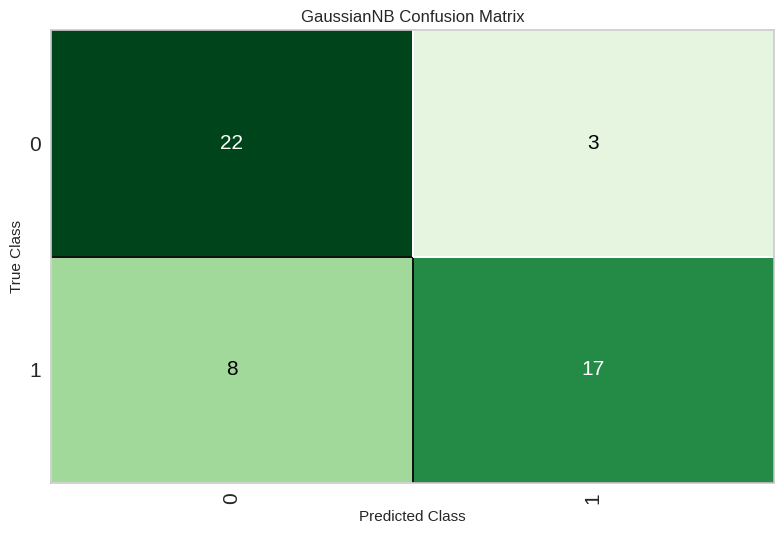

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Naive Bayes,0.7800,0.8464,0.6800,0.8500,0.7556,0.5600,0.5715



Matriz de Confusão (holdout):
[[22  3]
 [ 8 17]]

Relatório de Classificação (holdout):
              precision    recall  f1-score   support

           0       0.73      0.88      0.80        25
           1       0.85      0.68      0.76        25

    accuracy                           0.78        50
   macro avg       0.79      0.78      0.78        50
weighted avg       0.79      0.78      0.78        50



In [6]:
from pycaret.classification import predict_model, plot_model
from sklearn.metrics import confusion_matrix, classification_report

melhor_modelo = best_models[0]  # pega o modelo campeão do ranking

plot_model(melhor_modelo, plot='confusion_matrix')  # desenha a matriz de confusão no holdout

previsoes = predict_model(melhor_modelo)  # testa o modelo no holdout (dado nunca visto)

print("\nMatriz de Confusão (holdout):")
print(confusion_matrix(previsoes[TARGET], previsoes['prediction_label']))  # real vs previsto

print("\nRelatório de Classificação (holdout):")
print(classification_report(previsoes[TARGET], previsoes['prediction_label']))  # precisão/recall/F1 por classe


## melhor modelo: Naive Bayes

**1) Matriz de confusão / overfitting**

| | Previsto 0 | Previsto 1 |
|---|---|---|
| Real 0 (baixo risco, n=25) | 22 | 3 |
| Real 1 (alto risco, n=25) | 8 | 17 |

- CV (treino): Acurácia 0.75 / F1 0.75 → Holdout: Acurácia 0.78 / F1 0.76 — resultado se manteve (até melhorou levemente), **sem overfitting**.

**2) Acurácia e F1-Score**

- Acurácia (78%) é confiável aqui porque a base é balanceada (125 x 125).
- Dummy (chute aleatório) tira 50%; Naive Bayes tira 78% — diferença de 28 pontos, padrão forte.
- F1 por classe mais equilibrado: 0.80 (baixo risco) vs 0.76 (alto risco).

treinamento teve efeito real e forte. Modelo está **mais próximo de uso prático**, mas ainda erra 8 de 25 pacientes de alto risco (falso negativo perigoso na saúde)


